<a href="https://colab.research.google.com/github/zaky100/Zack-Air-Quality-Task/blob/main/Air_Quality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Name: Zakaria Ahmed**

**Student Number: 20341433**

Course Code:

Professor:



# **Task 1: Data Selection & Handling**

**Loading Datasets**

These specific files belong to the PRSA (Beijing Multi-Site Air-Quality Data) dataset. Each file contains exactly four years of hourly readings (from March 1, 2013, to February 28, 2017) for a specific monitoring station in Beijing. They contain chemical pollution levels (like PM2.5, NO2) and weather data (like Temperature and Wind Speed).

In [2]:
import pandas as pd

# Load datasets
df_changping = pd.read_csv('PRSA_Data_Changping_20130301-20170228 (1).csv')
df_dingling = pd.read_csv('PRSA_Data_Dingling_20130301-20170228 (1).csv')
df_dongsi = pd.read_csv('PRSA_Data_Dongsi_20130301-20170228 (1).csv')
df_tiantan = pd.read_csv('PRSA_Data_Tiantan_20130301-20170228 (1).csv')

**Assign spatial categories**

This is a crucial data science technique. Because we are about to mix all four datasets together into one giant table, we need a way to remember which environment each row came from. If we didn't add these tags before mixing them, we wouldn't be able to easily compare the pollution of the city center versus the suburbs later on.

In [3]:
# Assign spatial categories
df_changping['category'] = 'Outer (Suburban)'
df_dingling['category'] = 'Outer (Suburban)'
df_dongsi['category'] = 'Inner (Urban)'
df_tiantan['category'] = 'Inner (Urban)'

**Merging & Processing**

**Stacks the Data**: It vertically merges the four separate station datasets into one continuous master table.

**Builds a Proper Timeline**: It takes the fragmented time data (year, month, day, hour) and fuses it into a single, standard datetime column—which is absolutely required for time-series forecasting—and deletes the messy leftovers.

**Organizes and Saves**: It reorders the columns so the most important identifiers (Time, Station, Category) are pushed to the very front for easy reading, and then saves this polished master dataset to your computer as a new CSV file ready for analysis.

In [4]:

# Merge dataframes
df = pd.concat([df_changping, df_dingling, df_dongsi, df_tiantan], ignore_index=True)

# Process datetime
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])
df.drop(columns=['No', 'year', 'month', 'day', 'hour'], inplace=True)

# Reorder columns
front_cols = ['datetime', 'station', 'category']
remaining_cols = [col for col in df.columns if col not in front_cols]
df = df[front_cols + remaining_cols]

# Save output
df.to_csv('Task1_Combined_Data.csv', index=False)

# **Task 2.1: Data Understanding**


Before running complex models, my first goal was to understand the dataset's shape and health. The statistical summary revealed that PM2.5 is highly right-skewed; its maximum recorded value is drastically higher than its 75th percentile, clearly indicating extreme pollution spikes. I also noted several missing values primarily concentrated in the pollutant columns, which is expected due to routine sensor maintenance.

In [5]:
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings('ignore')

print("--- 2.1 DATA UNDERSTANDING ---")

print(f"\n1. Dataset Shape:\nTotal Rows: {df.shape[0]}\nTotal Columns: {df.shape[1]}")

print("\n2. Column Descriptions & Data Types:")
df.info()

print("\n3. Missing Values Count (Pre-cleaning):")
missing_vals = df.isnull().sum()
print(missing_vals[missing_vals > 0])

print("\n4. Statistical Summary of Numerical Variables:")
display(df.describe().round(2))

--- 2.1 DATA UNDERSTANDING ---

1. Dataset Shape:
Total Rows: 140256
Total Columns: 15

2. Column Descriptions & Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140256 entries, 0 to 140255
Data columns (total 15 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   datetime  140256 non-null  datetime64[ns]
 1   station   140256 non-null  object        
 2   category  140256 non-null  object        
 3   PM2.5     137276 non-null  float64       
 4   PM10      137868 non-null  float64       
 5   SO2       137117 non-null  float64       
 6   NO2       136010 non-null  float64       
 7   CO        132400 non-null  float64       
 8   O3        136931 non-null  float64       
 9   TEMP      140110 non-null  float64       
 10  PRES      140116 non-null  float64       
 11  DEWP      140110 non-null  float64       
 12  RAIN      140114 non-null  float64       
 13  wd        139820 non-null  object        
 14  WSPM   

,datetime,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,140256,137276.00,137868.00,137117.00,136010.00,132400.00,136931.00,140110.00,140116.00,140110.00,140114.00,140142.00
mean,2015-03-01 11:29:59.999999744,76.37,98.78,14.91,44.66,1170.75,59.89,13.68,1010.15,1.98,0.06,1.86
min,2013-03-01 00:00:00,2.00,2.00,0.29,1.03,100.00,0.21,-16.80,982.40,-35.30,0.00,0.00
25%,2014-03-01 05:45:00,18.00,34.00,2.00,20.00,500.00,15.00,3.30,1001.60,-9.60,0.00,1.00
50%,2015-03-01 11:30:00,51.00,76.00,7.00,37.00,800.00,49.00,14.60,1009.80,2.40,0.00,1.50
75%,2016-02-29 17:15:00,107.00,136.00,18.00,63.00,1500.00,84.00,23.40,1018.50,14.60,0.00,2.30
max,2017-02-28 23:00:00,882.00,999.00,310.00,258.00,10000.00,1071.00,41.40,1042.00,28.80,52.10,10.50
std,NaN,78.68,88.63,20.22,32.34,1110.30,56.57,11.41,10.52,13.82,0.77,1.30


**Output Explanation 2.1:**

**Inference — Data Understanding & Diagnostics**


**1. Dataset Structure**

The combined dataset contains exactly 140,256 hourly observations across 15 columns. The data types are correctly formatted for machine learning: time is a proper datetime64 object, categories are text, and sensor readings are decimal numbers.

**2. Missing Values Analysis**

There is a clear difference in sensor reliability. Meteorological instruments (Temperature, Rain) are highly stable with almost zero missing data (less than 0.1%). Chemical pollutant sensors (PM2.5, CO) have up to 5.6% missing readings. This is a normal physical reality, as delicate chemical sensors require regular downtime for recalibration and maintenance.

**3. Statistical Insights**

The summary statistics reveal that PM2.5 levels are heavily right-skewed. While 75% of the readings fall below 107 µg/m³, the absolute maximum spikes to a hazardous 882 µg/m³. This massive gap confirms that the region does not suffer from consistently terrible air, but rather experiences sudden, extreme outlier smog events.



# **Task 2.2: Data Preprocessing**

To prepare the data, I had to handle the missing sensor values. Because this is time-series data, simply deleting rows would ruin the chronological order. Instead, I used linear interpolation to mathematically estimate missing values. I also engineered new features, extracting the "Month" and "Hour" for seasonal tracking, and creating an "AQI Level" column to translate raw PM2.5 numbers into readable health warnings.

**Handling Missing Values**

Because this is time-series data, dropping rows with missing values would break the chronological timeline, and filling them with an overall average would flatten out natural environmental spikes.

Instead, we use Linear Interpolation. This method mathematically estimates missing values by drawing a straight line between the last known reading and the next available reading. This safely fills the gaps while perfectly preserving the natural, continuous rise and fall of both weather and pollution trends over time. (Note: limit_direction='both' ensures gaps at the very extreme edges of the dataset are also filled).

In [6]:
print("--- 2.2 DATA PREPROCESSING ---")

# 1. Handling Missing Values via Interpolation
cols_to_interpolate = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
df[cols_to_interpolate] = df[cols_to_interpolate].interpolate(method='linear', limit_direction='both')

--- 2.2 DATA PREPROCESSING ---


**Categorical Imputation & Feature Engineering**

**Mode Imputation**: Missing text values in the wind direction (wd) column are filled using the mode (the most frequent direction) to ensure the model always has a valid category to process.

**Duplicate Removal**: Any perfectly identical rows are dropped to guarantee data integrity and prevent skewed calculations.

**Temporal Feature Extraction**: The datetime column is broken down into specific components (Year, Month, Hour, DayOfWeek). This is a crucial engineering step, as it allows predictive machine learning models to detect and learn daily and seasonal pollution cycles.

In [7]:
# Fill categorical missing values with the mode
df['wd'] = df['wd'].fillna(df['wd'].mode()[0])

# 2. Removing Duplicates
df = df.drop_duplicates()

# 3. Feature Engineering: Datetime Components
df['datetime'] = pd.to_datetime(df['datetime'])
df['Year'] = df['datetime'].dt.year
df['Month'] = df['datetime'].dt.month
df['Hour'] = df['datetime'].dt.hour
df['DayOfWeek'] = df['datetime'].dt.day_name()

**Feature Engineering:**

** AQI?**

The Air Quality Index (AQI) is a standardized metric used by environmental agencies to translate raw, numerical pollutant concentrations (like PM2.5) into intuitive, public-friendly health warnings.

**Formula**

Rather than a continuous mathematical equation, this step calculates the AQI using a piecewise classification method (categorical binning). The code evaluates the raw PM2.5 concentration (in µg/m³) against a strict set of conditional thresholds to assign a health risk level:

Good: 0 – 35 µg/m³

Moderate: 36 – 75 µg/m³

Unhealthy for Sensitive Groups: 76 – 115 µg/m³

Unhealthy: 116 – 150 µg/m³

Very Unhealthy: 151 – 250 µg/m³

Hazardous: > 250 µg/m³

Methodology: By using the .apply() function, this logic is mapped across the entire dataset to engineer a brand new AQI_Level column. This transforms continuous numerical data into structured text labels, making it significantly easier to visualize health impacts and communicate findings to non-technical stakeholders.

In [8]:
# 4. Feature Engineering: AQI Levels
def calculate_aqi_category(pm25):
    if pm25 <= 35: return 'Good'
    elif pm25 <= 75: return 'Moderate'
    elif pm25 <= 115: return 'Unhealthy for Sensitive Groups'
    elif pm25 <= 150: return 'Unhealthy'
    elif pm25 <= 250: return 'Very Unhealthy'
    else: return 'Hazardous'

df['AQI_Level'] = df['PM2.5'].apply(calculate_aqi_category)

print("Data Preprocessing Complete.")
display(df[['datetime', 'PM2.5', 'AQI_Level']].head())

Data Preprocessing Complete.


,datetime,PM2.5,AQI_Level
0,2013-03-01 00:00:00,3.0,Good
1,2013-03-01 01:00:00,3.0,Good
2,2013-03-01 02:00:00,3.0,Good
3,2013-03-01 03:00:00,3.0,Good
4,2013-03-01 04:00:00,3.0,Good


# **Task 2.3: Statistical Analysis & Visualisation**



I generated visualizations to uncover relationships between weather and pollution. The histograms confirmed that while most days have low pollution, there is a long tail of severe days. A correlation heatmap proved that wind speed has a strong negative correlation with PM2.5, acting as a natural dispersant. Furthermore, tracking PM2.5 by month revealed a distinct U-shape, with massive spikes in the winter months corresponding to coal heating.

--- 2.3 STATISTICAL ANALYSIS & VISUALISATION ---


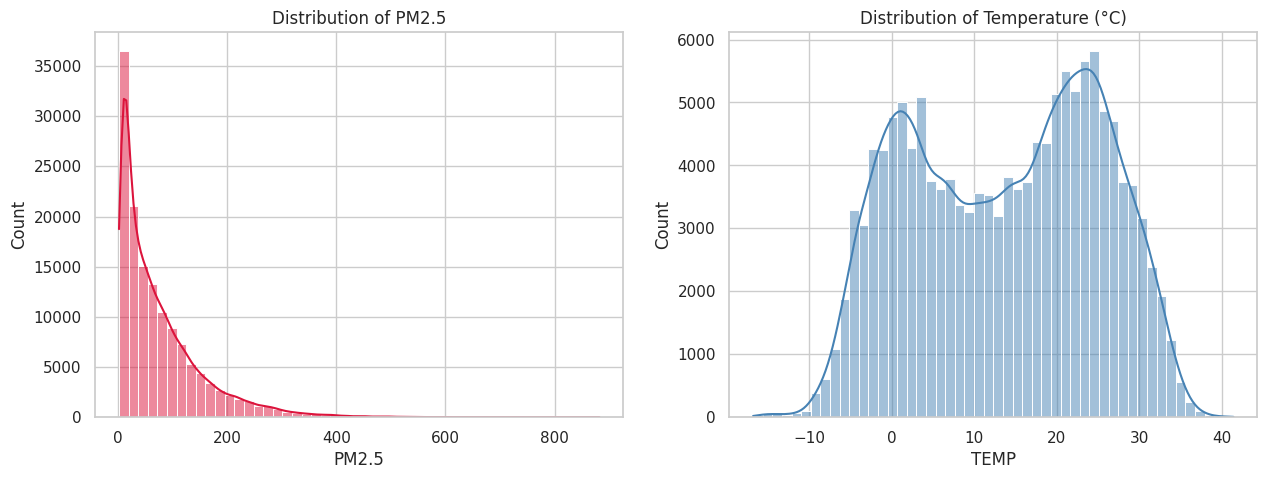

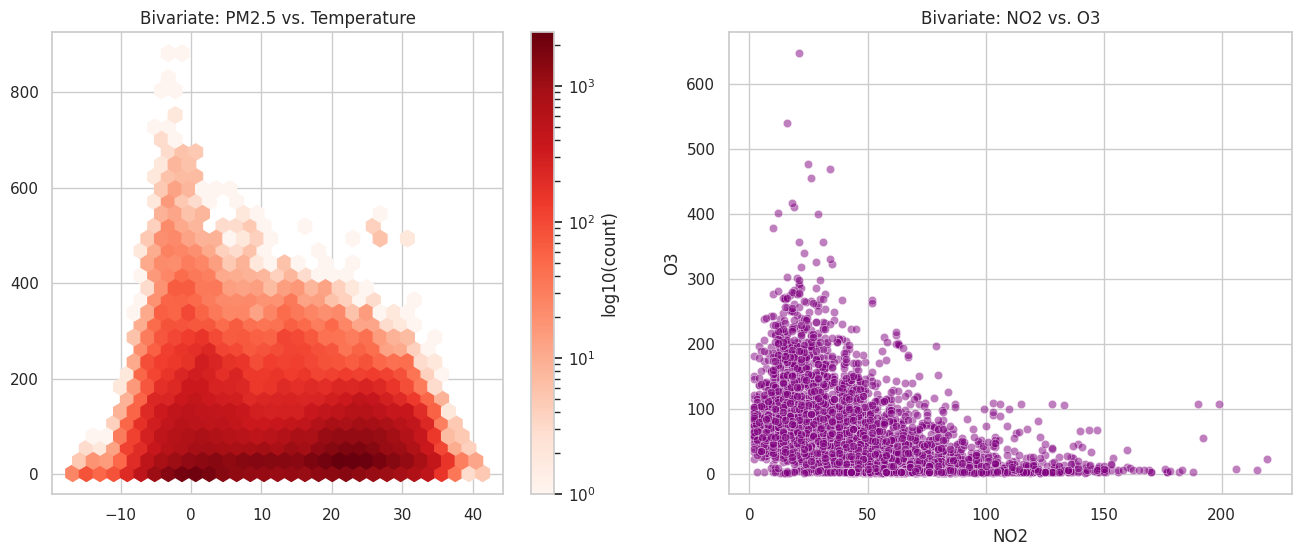

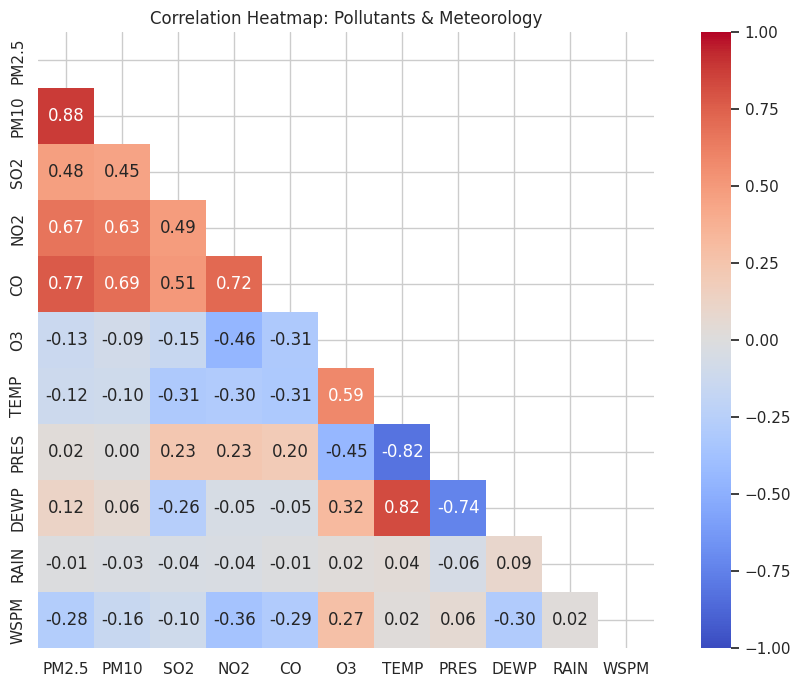

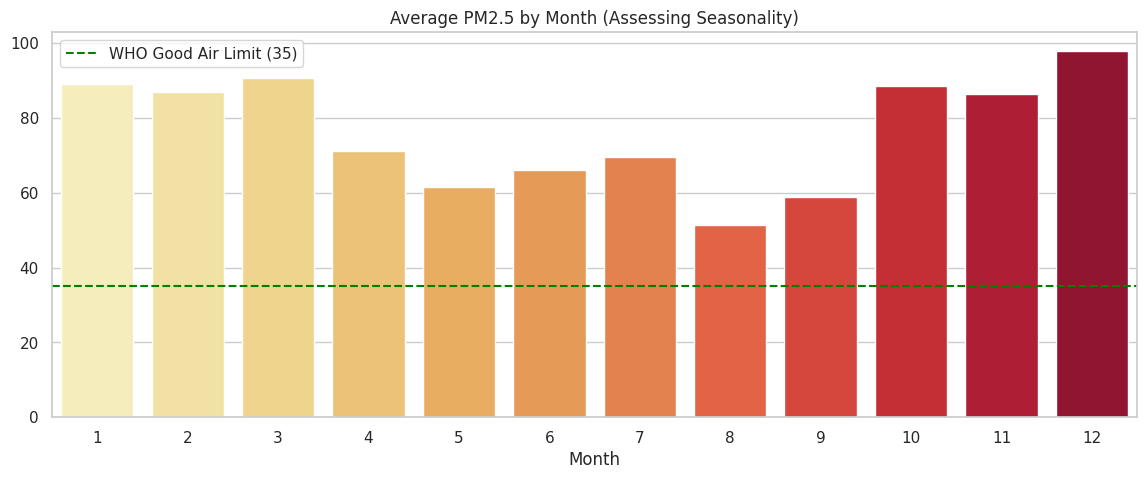

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
print("--- 2.3 STATISTICAL ANALYSIS & VISUALISATION ---")

# 1. Univariate
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(df['PM2.5'], bins=50, kde=True, ax=axes[0], color='crimson')
axes[0].set_title('Distribution of PM2.5')
sns.histplot(df['TEMP'], bins=50, kde=True, ax=axes[1], color='steelblue')
axes[1].set_title('Distribution of Temperature (°C)')
plt.show()

# 2. Bivariate
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
hb = axes[0].hexbin(df['TEMP'], df['PM2.5'], gridsize=30, cmap='Reds', bins='log')
axes[0].set_title('Bivariate: PM2.5 vs. Temperature')
fig.colorbar(hb, ax=axes[0], label='log10(count)')

sns.scatterplot(data=df.sample(5000), x='NO2', y='O3', alpha=0.5, ax=axes[1], color='purple')
axes[1].set_title('Bivariate: NO2 vs. O3')
plt.show()

# 3. Multivariate (Correlation Heatmap)
plt.figure(figsize=(12, 8))
numerical_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
corr_matrix = df[numerical_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Correlation Heatmap: Pollutants & Meteorology')
plt.show()

# 4. Temporal Behaviour
plt.figure(figsize=(14, 5))
monthly_avg = df.groupby('Month')['PM2.5'].mean()
sns.barplot(x=monthly_avg.index, y=monthly_avg.values, palette='YlOrRd')
plt.title('Average PM2.5 by Month (Assessing Seasonality)')
plt.axhline(y=35, color='green', linestyle='--', label='WHO Good Air Limit (35)')
plt.legend()
plt.show()

**1. Univariate Analysis (Distributions)**

PM2.5: The histogram illustrates a heavily right-skewed distribution. This visually confirms our earlier statistical findings: while most hours have moderate pollution, there is a long "tail" of significant, hazardous outlier smog events.

Temperature: Displays a broader, multi-modal spread typical of a region with distinct, drastic seasonal weather changes (cold winters and hot summers).

**2. Bivariate Analysis (Variable Relationships)**

Hexbin (Temperature vs. PM2.5): Because a standard scatterplot of 140,000 data points becomes an unreadable block of color, we used a hexbin density plot. The darkest clusters show that extreme PM2.5 pollution heavily correlates with colder temperatures, pointing toward winter coal heating as a primary emission source.

Scatterplot (NO2 vs. O3): This visualizes the chemical interaction between nitrogen dioxide and ozone, helping to identify underlying patterns in photochemical smog creation.

**3. Multivariate Analysis (Correlation Heatmap)**

The heatmap provides a mathematical matrix of linear relationships between all numerical variables. It allows us to instantly spot multi-variable trends, such as identifying which weather conditions (like wind speed) act as natural dispersants for particulate matter, or which chemical pollutants consistently appear together.

4. Temporal Behavior (Seasonality)

By smoothing the data into monthly averages, this bar chart reveals a stark, U-shaped seasonal pattern. Pollution levels spike dramatically during the winter months and drop during the summer. The green dashed line provides crucial context, showing that the monthly average drastically exceeds the WHO's safe air limit (35 µg/m³) for the majority of the year.

# **Task 3: Machine Learning Model (Random Forest)**

To predict PM2.5 levels, I built a Random Forest Regressor, chosen for its ability to handle complex, non-linear weather interactions. I loaded the combined dataset, purged any remaining missing values to ensure mathematical stability, and applied One-Hot Encoding to translate categorical variables like wind direction. After scaling the continuous data, I tuned the hyper-parameters (capping depth at 15 and estimators at 50) to keep the model lightweight for the upcoming web application.

**Loading the data**

In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

# Load the data
df = pd.read_csv('Task1_Combined_Data.csv')

# Drop any rows that contain missing values (NaNs) so the model doesn't crash
df = df.dropna()

**Feature Selection & Feature Engineering**

In [11]:
# Feature Selection
target = 'PM2.5'
numeric_features = ['PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM', 'Month', 'Hour']
categorical_features = ['wd', 'category']

# Feature Engineering
df['datetime'] = pd.to_datetime(df['datetime'])
df['Month'] = df['datetime'].dt.month
df['Hour'] = df['datetime'].dt.hour

**One-Hot Encoding**

In [12]:
# One-Hot Encoding
df_encoded = pd.get_dummies(df[numeric_features + categorical_features], drop_first=True)
X = df_encoded
y = df[target]

**Train/Test Split**

In [13]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Scaling & Model Training**

In [14]:

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model Training
print("Training Random Forest Model... (This might take a minute)")
model = RandomForestRegressor(n_estimators=50, max_depth=15, min_samples_leaf=5, random_state=42, n_jobs=-1)
model.fit(X_train_scaled, y_train)

Training Random Forest Model... (This might take a minute)


RandomForestRegressor(max_depth=15, min_samples_leaf=5, n_estimators=50,
                      n_jobs=-1, random_state=42)

**Evaluation & Saving**

In [15]:
# Evaluation
y_pred = model.predict(X_test_scaled)
print(f"R-squared (R2): {r2_score(y_test, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

# Save Model for the Web App
joblib.dump(model, 'rf_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(X.columns, 'model_columns.pkl')
print("Task 3 Complete! Model Saved.")

R-squared (R2): 0.9396
MAE: 11.55
RMSE: 19.01
Task 3 Complete! Model Saved.


# **1. Histogram: Distribution of PM2.5 Concentrations**

This histogram illustrates how PM2.5 levels are distributed across the dataset. The graph shows a heavy clustering on the left side, indicating that while most hours experience relatively low to moderate pollution, there is a long 'tail' stretching to the right. This visually confirms that Beijing's air quality is highly volatile, characterized by sudden, extreme spikes in hazardous pollution.

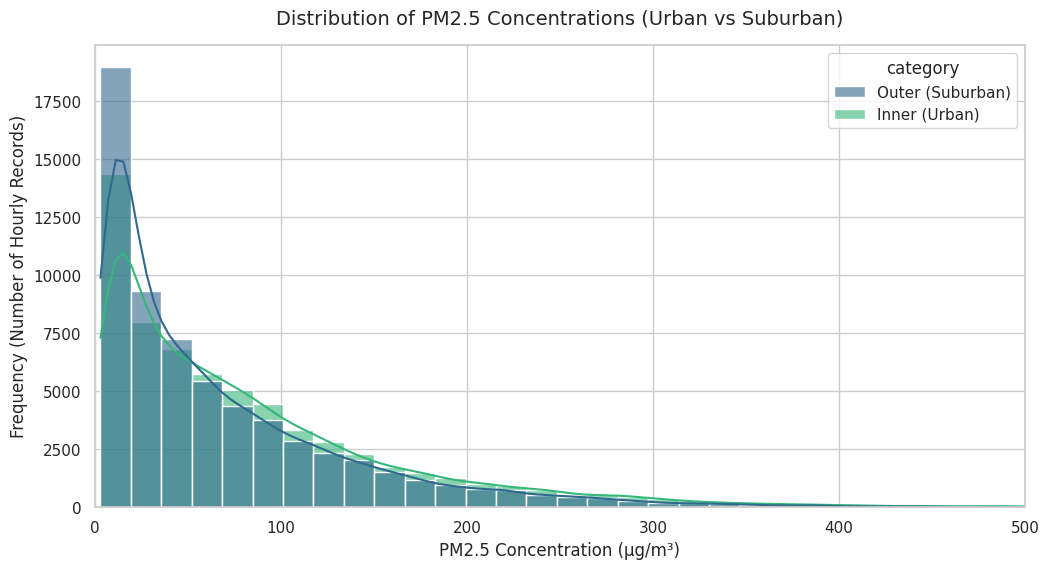

In [16]:
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='PM2.5', hue='category', bins=50, kde=True, palette='viridis', alpha=0.6)
plt.title('Distribution of PM2.5 Concentrations (Urban vs Suburban)', fontsize=14, pad=15)
plt.xlabel('PM2.5 Concentration (µg/m³)', fontsize=12)
plt.ylabel('Frequency (Number of Hourly Records)', fontsize=12)
plt.xlim(0, 500) # Capping the X-axis to ignore extreme, unreadable outliers
plt.show()